### 2.5 SVM（支持向量机）

> **做什么**：寻找最大间隔超平面进行分类，核技巧处理非线性 

- ### **SVM实操**

<br/>

1.鸢尾花SVM决策边界可视化

准确率: 0.7333


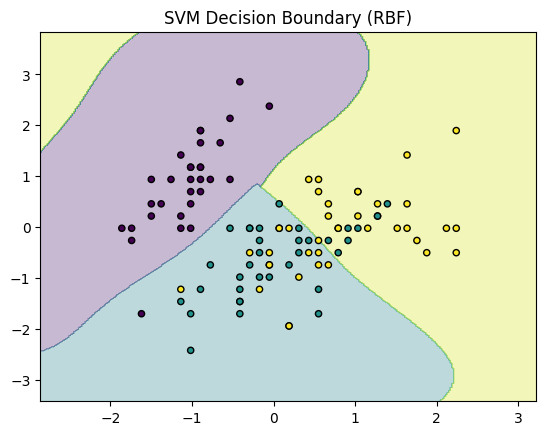

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

# 加载数据，只用前两个特征方便可视化
iris = load_iris()
X = iris.data[:, :2]  # 花萼长度、花萼宽度
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 训练SVM（RBF核）
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")

# 可视化决策边界
import matplotlib.pyplot as plt
h = 0.02  # 网格步长
x_min, x_max = X_train_s[:, 0].min()-1, X_train_s[:, 0].max()+1
y_min, y_max = X_train_s[:, 1].min()-1, X_train_s[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, s=20, edgecolor='k')
plt.title('SVM Decision Boundary (RBF)')
plt.show()

# 关键参数: kernel('linear'/'rbf'/'poly'), C(惩罚参数), gamma(核宽度)

2.基于支持向量机实现对IMDB 电影评论进行分类，要求如下：

（1）加载IMDB Dataset.csv数据集；

（2）使用pandas查看iloc方法查看review评论列；

（3）将sentiment情感列的positive转为数值型1, negative转为数值型0；

（4）使用nltk下载停用词表；

（5）定义去除html标签的方法strip_html(text)；

（6）定义清理文本的方法clean_text(text)（去除html标签，字符转为小写，保留非停用词，按空格分隔英语单词，然后重新组装一个字符串）；

（7）对review列使用clean_text(text)方法进行文本清理；

（8）选取前10000条数据作为数据集，然后使用sklearn的train_test_split拆分数据集为训练集和测试集（20%）；

（9）使用sklearn.feature_extraction.text.CountVectorizer类构建单词矩阵；

（10）建立支持向量机模型；

（11）对测试集进行预测；

（12）打印测试集准确率accuracy_score分数；

（13）使用pickle包将模型以文件名model_svm_movie.sav保存到磁盘；

（14）加载model_svm_movie.sav模型，对测试集进行预测

In [5]:
!pip install nltk

Looking in indexes: https://mirrors.ustc.edu.cn/pypi/web/simple
     ---------------------------------------- 1.5/1.5 MB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 98.2/98.2 kB ? eta 0:00:00
     ------------------------------------- 269.6/269.6 kB 16.2 MB/s eta 0:00:00
     ---------------------------------------- 78.6/78.6 kB ? eta 0:00:00


In [6]:
import pandas as pd
import re
import pickle
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# (1) 加载IMDB Dataset.csv数据集
df = pd.read_csv("D:/JupyterNotebook/IMDB_Dataset.csv")
print(f"数据集形状: {df.shape}")
print(df.head())

# (2) 使用iloc查看review评论列
print("\n===== 前5条评论 =====")
print(df.iloc[:, 0].head())  # review列
print("\n===== 前5条情感标签 =====")
print(df.iloc[:, 1].head())  # sentiment列

# (3) 将sentiment转为数值型：positive→1, negative→0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"\n转换后情感标签分布:\n{df['sentiment'].value_counts()}")

# (4) 下载nltk停用词表
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
print(f"停用词数量: {len(stop_words)}")

# (5) 定义去除html标签的方法
def strip_html(text):
    """去除HTML标签，如<br />, <a href=...>等"""
    return re.sub(r'<[^>]+>', '', text)

# (6) 定义清理文本的方法
def clean_text(text):
    """去除html标签 → 转小写 → 去停用词 → 按空格分词 → 重组字符串"""
    text = strip_html(text)             # 去除html标签
    text = text.lower()                  # 转小写
    words = text.split()                 # 按空格分隔
    words = [w for w in words if w not in stop_words]  # 去停用词
    return ' '.join(words)               # 重组字符串

# 测试clean_text
sample = df.iloc[0, 0]
print(f"\n原始评论（前200字）: {sample[:200]}")
print(f"清理后（前200字）: {clean_text(sample)[:200]}")

# (7) 对review列使用clean_text进行文本清理
print("\n正在清理文本，请稍候...")
df['review'] = df['review'].apply(clean_text)
print("文本清理完成！")

# (8) 选取前10000条，拆分训练集和测试集(20%)
X = df['review'].iloc[:10000]
y = df['sentiment'].iloc[:10000]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\n训练集大小: {len(X_train)}, 测试集大小: {len(X_test)}")

# (9) 使用CountVectorizer构建单词矩阵
vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"单词矩阵形状: {X_train_vec.shape}")

# (10) 建立SVM模型
svm_model = SVC(kernel='linear', random_state=42)
print("\n正在训练SVM模型，请稍候...")
svm_model.fit(X_train_vec, y_train)

# (11) 对测试集进行预测
y_pred = svm_model.predict(X_test_vec)

# (12) 打印准确率
acc = accuracy_score(y_test, y_pred)
print(f"\nSVM测试集准确率: {acc:.4f}")

# (13) 使用pickle将模型保存到磁盘
with open('model_svm_movie.sav', 'wb') as f:
    pickle.dump(svm_model, f)
print("模型已保存: model_svm_movie.sav")

# (14) 加载模型，对测试集进行预测
with open('model_svm_movie.sav', 'rb') as f:
    loaded_model = pickle.load(f)
y_pred_loaded = loaded_model.predict(X_test_vec)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"加载模型后准确率: {acc_loaded:.4f}")

数据集形状: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

===== 前5条评论 =====
0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object

===== 前5条情感标签 =====
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

转换后情感标签分布:
1    25000
0    25000
Name: sentiment, dtype: int64


[nltk_data] Error loading stopwords: HTTP Error 502: Bad Gateway


停用词数量: 179

原始评论（前200字）: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
清理后（前200字）: one reviewers mentioned watching 1 oz episode hooked. right, exactly happened me.the first thing struck oz brutality unflinching scenes violence, set right word go. trust me, show faint hearted timid.

正在清理文本，请稍候...
文本清理完成！

训练集大小: 8000, 测试集大小: 2000
单词矩阵形状: (8000, 5000)

正在训练SVM模型，请稍候...

SVM测试集准确率: 0.8310
模型已保存: model_svm_movie.sav
加载模型后准确率: 0.8310


### 2.6 Random Forest（随机森林）

> **做什么**：多棵决策树投票（Bagging+特征随机）  
> **经典案例**：手写数字分类（8x8灰度图，1797个样本）

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 加载手写数字数据集（8x8像素）
digits = load_digits()
X, y = digits.data, digits.target  # 64个像素特征 -> 10个数字类别

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# 训练随机森林
model = RandomForestClassifier(
    n_estimators=100,   # 100棵树
    max_depth=10,       # 每棵树最大深度
    random_state=42,
    n_jobs=-1           # 使用所有CPU核心加速
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")

# 特征重要性前5
top5 = np.argsort(model.feature_importances_)[-5:][::-1]
print(f"最重要的5个像素位置: {top5}")

# 关键参数：n_estimators(树数量), max_depth, min_samples_leaf, bootstrap=True

准确率: 0.9778
最重要的5个像素位置: [36 21 43 26 42]


### 2.7 Gradient Boosting（梯度提升）

> **做什么**：序列化建树，每棵树拟合前一轮残差  
> **经典案例**：Adult收入预测（预测收入是否>50K）

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 用手写数字数据集（内置，不用联网）
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42
)

model = GradientBoostingClassifier(
    n_estimators=100,     # 提升轮数
    learning_rate=0.1,    # 学习率
    max_depth=5,          # 每棵树深度
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")

# 关键参数: n_estimators, learning_rate, max_depth, subsample(行采样比例)

准确率: 0.9611
